## **Week 7 LLM Engineering Exercise** 
### **Open Source LLM Fine-Tuning with QLoRA**

**Quick Recap:**
- Our LLM use case is to predict football player's market value (in €) based on the player's attributes summary
- From Week 6, we already had the pre-processed dataset (player name and their summary) and baseline accuracy using GPT-5.1 which achieved error of ~ € 1,400,000
- In Week 7, we are going to load the dataset, re-format into Prompt & Completion structure, and execute model training using SFT Trainer and QLoRA method

**Step-by-step:** (*some parts are in separate .ipynb*)
1. Dataset truncation [scope of this _part2-1.ipynb]
2. Training dataset re-formatting [scope of this _part2-1.ipynb]
3. Initialize hyperparameters [scope of separate notebook; _part2-2.ipynb]
4. Load the open source model with quantization [scope of separate notebook; _part2-2.ipynb]
5. Initiate and run the training using SFT Trainer [scope of separate notebook; _part2-2.ipynb]
6. Perform market value prediction using the fine-tuned model [scope of separate notebook; _part2-2.ipynb]

*Steps 3-6 will be iterative and performed in Google Colab*

### **1. Dataset truncation to optimize token length**

**1.1. Load final dataset**

In [1]:
# Imports

import os
from dotenv import load_dotenv
from huggingface_hub import login

from mv_estimator.mv_items import PlayerItem
# Disclaimer: new function is added under PlayerItem class: count_tokens

from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

In [2]:
# Credentials
load_dotenv(override=True)
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [34]:
# Login and load the dataset
username = "farrasezra"
dataset = f"{username}/football_mv_clean_full"

train, val, test = PlayerItem.from_hub(dataset)
items = train + val + test

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

Loaded 33,000 training items, 4,000 validation items, 3,563 test items


**1.2. Analyze token length distribution to determine cutoff size**

In [35]:
# Initiate tokenizer
BASE_MODEL = "meta-llama/Llama-3.2-3B" # LLM that will do tokenization
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

In [36]:
# Define array to store token size for each data points
token_counts = [item.count_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/40563 [00:00<?, ?it/s]

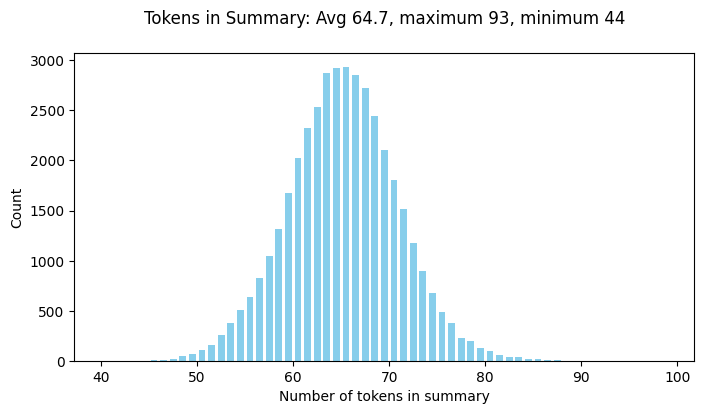

In [37]:
# Plot the token length distribution of overall dataset
plt.figure(figsize=(8, 4))
plt.title(f"Tokens in Summary: Avg {sum(token_counts)/len(token_counts):,.1f}, maximum {max(token_counts):,}, minimum {min(token_counts):,}\n")
plt.xlabel('Number of tokens in summary')
plt.ylabel('Count')
plt.hist(token_counts, rwidth=0.7, color="skyblue", bins=range(40, 100, 1))
plt.show()

In [38]:
# Determine how many rows/players will be truncated from the dataset

CUTOFF = 75
cut = len([count for count in token_counts if count > CUTOFF])
print(f"With this CUTOFF, we will truncate {cut:,} items which is {cut/len(items):.1%}")

With this CUTOFF, we will truncate 1,216 items which is 3.0%


**1.3. Do the dataset truncation**

and

**2.1. Run dataset re-formatting**

In [39]:
# Loop truncation and dataset re-formatting into PROMPT & COMPLETION
# do_round set to True (to avoid decimal values)

for item in tqdm(train+val):
    item.make_prompts(tokenizer, CUTOFF, True)
for item in tqdm(test):
    item.make_prompts(tokenizer, CUTOFF, True)

  0%|          | 0/37000 [00:00<?, ?it/s]

  0%|          | 0/3563 [00:00<?, ?it/s]

**1.4. Re-calculate the token counts and check new token distributions**

In [40]:
prompt_token_counts = [item.count_prompt_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/40563 [00:00<?, ?it/s]

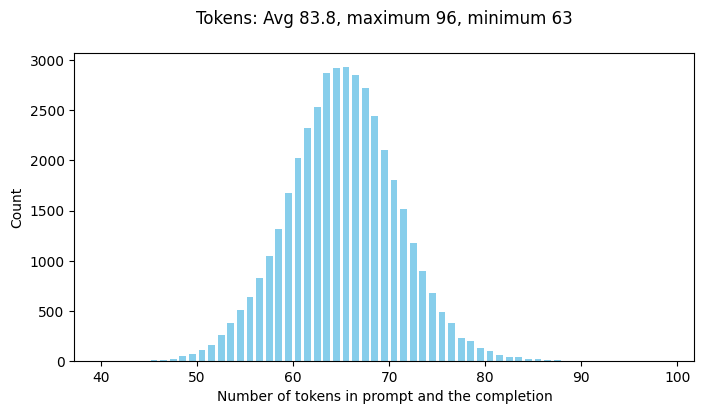

In [41]:
# Plot the token length distribution of overall dataset
plt.figure(figsize=(8, 4))
plt.title(f"Tokens: Avg {sum(prompt_token_counts)/len(prompt_token_counts):,.1f}, maximum {max(prompt_token_counts):,}, minimum {min(prompt_token_counts):,}\n")
plt.xlabel('Number of tokens in prompt and the completion')
plt.ylabel('Count')
plt.hist(token_counts, rwidth=0.7, color="skyblue", bins=range(40, 100, 1))
plt.show()

**2.2. Check the re-formatted dataset**

In [43]:
print("PROMPT:")
print(train[3].prompt)

PROMPT:
What is this football player's transfer market value to nearest euro?

Name: Kolbeinn Thórdarson  
Position: Midfield (Central Midfield)  
Club: Idrottsföreningen Kamraterna Göteborg  
Profile: A 26-year-old Icelandic central midfielder known for his tactical awareness.  
Attributes: Standing 177 cm tall and right-footed, he combines agility with precise ball control and distribution

Market value is €


In [44]:
print("COMPLETION:")
print(train[3].completion)

COMPLETION:
1200000


**2.3. Push the re-formatted dataset to Huggingface**

In [42]:
username = "farrasezra"
dataset = f"{username}/football_mv_prompts_full"

PlayerItem.push_prompts_to_hub(dataset, train, val, test)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/33 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]